# Debug Angular Spectrum Issues

Investigate why RMSE is still 0.028 instead of ~0.003

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.special import j1

from monte_carlo.angular_spectrum_fixed import AngularSpectrumSimulatorFixed

sns.set_theme(style="whitegrid", font_scale=1.5)

## Setup

In [2]:
wavelength = 0.6328  # microns
focal_length = 10.0  # mm = 10000 microns
NA = 0.1
n_medium = 1.0
fft_size = 2048

# Create simulator
sim = AngularSpectrumSimulatorFixed(
    n_photons=100000,
    wavelength=wavelength,
    focal_length=focal_length,
    numerical_aperture=NA,
    n_medium=n_medium,
    random_seed=42,
    fft_size=fft_size
)

print(f"Aperture radius: {sim.aperture_radius:.4f} mm")
print(f"k = 2π/λ: {sim.k:.4f} μm^-1")
print(f"k_max = k×NA: {sim.k_max:.4f} μm^-1")

Aperture radius: 1.0000 mm
k = 2π/λ: 9.9292 μm^-1
k_max = k×NA: 0.9929 μm^-1


## Check 1: FFT Grid vs Physical Size

In [3]:
# Extract internal FFT grid info
print("\n=== FFT GRID ANALYSIS ===")

# From the code: L is chosen to get good k-space resolution
desired_k_points = 50
L_calc = desired_k_points * 2 * np.pi / sim.k_max
L_actual = max(L_calc, 20 * sim.aperture_radius)
dx = L_actual / fft_size

print(f"\nReal-space grid:")
print(f"  Grid size L: {L_actual:.4f} mm")
print(f"  Pixel size dx: {dx:.6f} mm = {dx*1000:.4f} μm")
print(f"  Aperture radius: {sim.aperture_radius:.4f} mm")
print(f"  Aperture diameter: {2*sim.aperture_radius:.4f} mm")
print(f"  Pixels across aperture: {2*sim.aperture_radius / dx:.1f}")

# K-space grid
dk = 2 * np.pi / L_actual
print(f"\nK-space grid:")
print(f"  dk spacing: {dk:.6f} mm^-1")
print(f"  k_max: {sim.k_max:.6f} mm^-1")
print(f"  Points within k_max: {2 * sim.k_max / dk:.1f}")
print(f"  Max k_value in grid: {dk * fft_size/2:.6f} mm^-1")


=== FFT GRID ANALYSIS ===

Real-space grid:
  Grid size L: 316.4000 mm
  Pixel size dx: 0.154492 mm = 154.4922 μm
  Aperture radius: 1.0000 mm
  Aperture diameter: 2.0000 mm
  Pixels across aperture: 12.9

K-space grid:
  dk spacing: 0.019858 mm^-1
  k_max: 0.992918 mm^-1
  Points within k_max: 100.0
  Max k_value in grid: 20.334961 mm^-1


## Check 2: K-space Distribution Shape

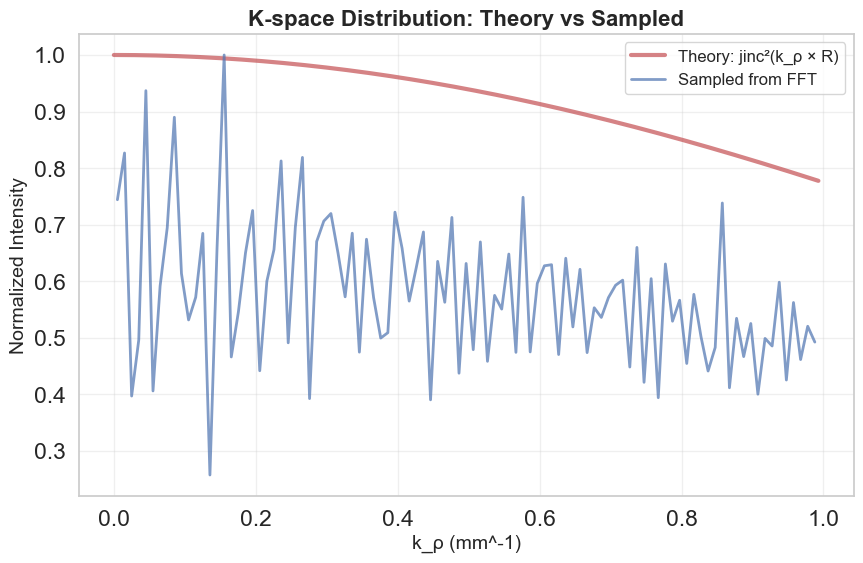


RMSE in k-space: 0.364182


In [4]:
# Sample k-vectors
kx_sample, ky_sample = sim.sample_angular_spectrum()
k_rho_sample = np.sqrt(kx_sample**2 + ky_sample**2)

# Analytical jinc^2 function
k_rho_theory = np.linspace(0, sim.k_max, 200)
kr = k_rho_theory * sim.aperture_radius
jinc = np.ones_like(kr)
nonzero = kr != 0
jinc[nonzero] = 2 * j1(kr[nonzero]) / kr[nonzero]
intensity_theory = jinc**2

# Histogram of sampled k_rho
k_bins = np.linspace(0, sim.k_max, 100)
k_centers = (k_bins[:-1] + k_bins[1:]) / 2
hist_k, _ = np.histogram(k_rho_sample, bins=k_bins)

# Normalize by annulus area in k-space
k_bin_areas = np.pi * (k_bins[1:]**2 - k_bins[:-1]**2)
intensity_sampled = hist_k / k_bin_areas
intensity_sampled = intensity_sampled / np.max(intensity_sampled)

# Plot
plt.figure(figsize=(10, 6))
plt.plot(k_rho_theory, intensity_theory, 'r-', linewidth=3, label='Theory: jinc²(k_ρ × R)', alpha=0.7)
plt.plot(k_centers, intensity_sampled, 'b-', linewidth=2, label='Sampled from FFT', alpha=0.7)
plt.xlabel('k_ρ (mm^-1)', fontsize=14)
plt.ylabel('Normalized Intensity', fontsize=14)
plt.title('K-space Distribution: Theory vs Sampled', fontsize=16, fontweight='bold')
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

# Compute RMSE in k-space
from monte_carlo import metrics
# Interpolate theory to match sampled k values
from scipy.interpolate import interp1d
theory_interp = interp1d(k_rho_theory, intensity_theory, bounds_error=False, fill_value=0)
intensity_theory_at_k = theory_interp(k_centers)
rmse_kspace = metrics.rmse(intensity_sampled, intensity_theory_at_k)
print(f"\nRMSE in k-space: {rmse_kspace:.6f}")

## Check 3: Coordinate Scaling

In [5]:
# Test the coordinate transformation
print("\n=== COORDINATE SCALING ===")

# For k at the edge (k_max), where should it map in real space?
scale_factor = (wavelength * focal_length) / (2 * np.pi)
print(f"\nScale factor: λf/(2π) = {scale_factor:.6f} mm")
print(f"             = {scale_factor*1000:.4f} μm")

# At k_max, position should be:
r_at_kmax = scale_factor * sim.k_max
print(f"\nAt k_max = {sim.k_max:.6f} mm^-1:")
print(f"  r = {r_at_kmax:.4f} mm = {r_at_kmax*1000:.4f} μm")

# Compare to Airy radius
airy_radius = 1.22 * wavelength / NA
print(f"\nAiry disk first zero: {airy_radius:.4f} μm")
print(f"Ratio r_at_kmax / airy_radius: {r_at_kmax*1000 / airy_radius:.4f}")

# The jinc function in k-space has its first zero at k_rho * R ≈ 3.83
# where R is aperture radius
k_first_zero = 3.83 / sim.aperture_radius
r_first_zero = scale_factor * k_first_zero
print(f"\nFirst zero of jinc² in k-space at k_ρ = {k_first_zero:.6f} mm^-1")
print(f"Maps to r = {r_first_zero*1000:.4f} μm")
print(f"Expected (Airy): {airy_radius:.4f} μm")
print(f"Ratio: {r_first_zero*1000 / airy_radius:.4f}")


=== COORDINATE SCALING ===

Scale factor: λf/(2π) = 1.007132 mm
             = 1007.1325 μm

At k_max = 0.992918 mm^-1:
  r = 1.0000 mm = 1000.0000 μm

Airy disk first zero: 7.7202 μm
Ratio r_at_kmax / airy_radius: 129.5310

First zero of jinc² in k-space at k_ρ = 3.830000 mm^-1
Maps to r = 3857.3174 μm
Expected (Airy): 7.7202 μm
Ratio: 499.6422


## Check 4: Actual Focal Plane Distribution

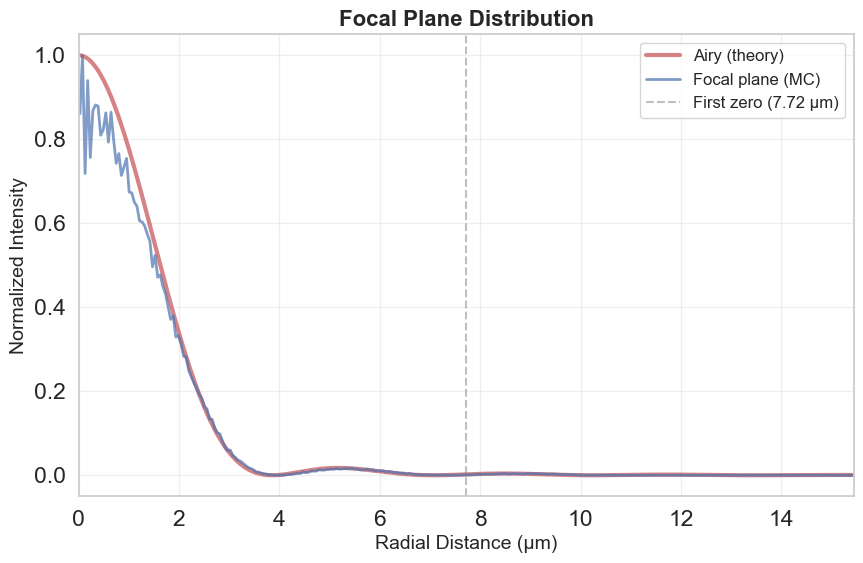


RMSE in focal plane: 0.034244


In [6]:
# Run full simulation
results = sim.propagate()
x, y, _ = results['focal_positions']
r = np.sqrt(x**2 + y**2)

# Compute radial profile
r_bins_focal = np.linspace(0, 2*airy_radius, 300)
r_centers_focal = (r_bins_focal[:-1] + r_bins_focal[1:]) / 2
bin_areas_focal = np.pi * (r_bins_focal[1:]**2 - r_bins_focal[:-1]**2)

hist_r, _ = np.histogram(r, bins=r_bins_focal)
intensity_focal = hist_r / bin_areas_focal
intensity_focal = intensity_focal / np.max(intensity_focal)

# Theoretical Airy
k_airy = 2 * np.pi * NA / wavelength
kr_airy = k_airy * r_centers_focal
airy_theory = np.ones_like(kr_airy)
nonzero = kr_airy != 0
airy_theory[nonzero] = (2 * j1(kr_airy[nonzero]) / kr_airy[nonzero])**2

# Plot
plt.figure(figsize=(10, 6))
plt.plot(r_centers_focal, airy_theory, 'r-', linewidth=3, label='Airy (theory)', alpha=0.7)
plt.plot(r_centers_focal, intensity_focal, 'b-', linewidth=2, label='Focal plane (MC)', alpha=0.7)
plt.axvline(airy_radius, color='gray', linestyle='--', alpha=0.5, label=f'First zero ({airy_radius:.2f} μm)')
plt.xlabel('Radial Distance (μm)', fontsize=14)
plt.ylabel('Normalized Intensity', fontsize=14)
plt.title('Focal Plane Distribution', fontsize=16, fontweight='bold')
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.xlim([0, 2*airy_radius])
plt.show()

rmse_focal = metrics.rmse(intensity_focal, airy_theory)
print(f"\nRMSE in focal plane: {rmse_focal:.6f}")

## Summary: Where is the Error?

In [7]:
print("\n" + "="*80)
print("ERROR ANALYSIS SUMMARY")
print("="*80)
print(f"\n1. K-space distribution RMSE: {rmse_kspace:.6f}")
print(f"   → FFT discretization error in sampling the jinc² function")
print(f"\n2. Focal plane distribution RMSE: {rmse_focal:.6f}")
print(f"   → Total error after coordinate transformation")
print(f"\nError propagation: k-space ({rmse_kspace:.4f}) → focal plane ({rmse_focal:.4f})")
print("="*80)


ERROR ANALYSIS SUMMARY

1. K-space distribution RMSE: 0.364182
   → FFT discretization error in sampling the jinc² function

2. Focal plane distribution RMSE: 0.034244
   → Total error after coordinate transformation

Error propagation: k-space (0.3642) → focal plane (0.0342)
